# Notebook demonstrating functionality of ensemble_stats package

## Overview

This package consists of three python scripts:

## 1. Statistical analysis and preprocessing utilities (analysis.py)

Contains utilities for preprocessing hierarchical ensemble timeseries, estimating persistence timescales, 
performing sliding-window, moving-block bootstrap (MBB) uncertainty analysis over time, and decomposing variance structure.

Functions include:

[optional pre-processing step]

- `compute_STL_decomposition`
  Compute the Seasonal Decomposition of Time Series by Loess (STL).

  Cleveland, R., Cleveland, W., McRae, J., & Terpenninng, I. (1990). STL: A Seasonal-Trend Decomposition Procedure Based on Loess. Journal of Official Statistics, 6(1), 3–73.

  (This works well with stationary and non-stationary timeseries. For a simpler version of the above, but only for stationary timeseries, use:)

- `remove_linear_trend`  
  Remove a prescribed linear temporal trend.

- `remove_seasonal_cycle`  
  Remove the mean monthly seasonal cycle.

[main analysis step]

- `validate_input_dims`  
  Validate required ensemble and temporal dimensions.

- `estimate_autocorrelation_timescale`  
  Estimate persistence timescale from autocorrelation decay.

- `estimate_mutual_information_timescale`  
  Estimate nonlinear persistence timescale from delayed mutual information.

- `define_block_length`  
  Determine an appropriate MBB block length from ensemble persistence statistics.

- `moving_block_bootstrap_indices`  
  Generate moving-block bootstrap resampling indices.

- `compute_block_statistics_anova`  
  Perform hierarchical ANOVA-style variance decomposition.

- `sliding_window_MBB_ensemble_analysis`  
  Apply sliding-window ensemble analysis with optional moving-block bootstrap uncertainty estimation.

[Diagnostic functions]

- `compute_relative_nonstationarity`  
  Quantify normalized temporal variability of a variance series.

- `compute_preprocessing_variance_statistics`  
  Compare ensemble variance statistics before and after preprocessing.


```mermaid
flowchart TD

    G["sliding_window_MBB_ensemble_analysis()"]

    %% Top-level validation
    G --> A["validate_input_dims()"]

    %% Main statistics pathway
    G --> F["compute_block_statistics_anova()"]

    %% Bootstrap pathway
    G --> E["moving_block_bootstrap_indices()"]
    E --> RNG["numpy.random.Generator"]

    %% Optional preprocessing dependency
    G -.uses externally supplied.-> D["define_block_length()"]

    %% Block-length estimation hierarchy
    D --> B["estimate_autocorrelation_timescale()"]
    D --> C["estimate_mutual_information_timescale()"]

    %% External library dependencies
    B --> ACF["statsmodels.tsa.stattools.acf"]

    C --> MI["sklearn.feature_selection.mutual_info_regression"]

    %% Internal loop structure annotations
    subgraph "Sliding Window Loop"
        G
        F
        E
    end

    subgraph "Persistence Estimation Subsystem"
        D
        B
        C
    end
```


## 2. Visualisation utilities (plotting.py)

Contains plotting utilities for diagnosing hierarchical ensemble structure, preprocessing effects, variance decomposition, and bootstrap uncertainty.

Functions include:

- `plot_STL_decomposition`

  Plot STL decomposition components of the grand ensemble-mean timeseries.  Seasonal Decomposition of Time Series by Loess (STL).
  
- `plot_groups_members`  
  Visualize nested ensemble members and highlighted realizations.

- `plot_preprocessing_components`  
  Compare original, detrended, and preprocessed signals.

- `plot_normalised_variance`  
  Compare normalized ensemble variance before and after preprocessing.

- `plot_distribution_comparison`  
  Compare empirical distributions of original and preprocessed data.

- `plot_variance_decomposition_timeseries`  
  Plot temporal evolution of variance decomposition components.

- `plot_fractional_variance_decomposition`  
  Plot fractional contributions of variance components.

- `plot_bootstrap_confidence_intervals`  
  Visualize bootstrap confidence intervals for selected statistics.

- `plot_member_spaghetti`  
  Display all ensemble realizations and ensemble mean.

- `plot_example_window_decomposition`  
  Inspect mean structure within a selected sliding window.

## 3. Synthetic hierarchical ensemble generator (synthetic.py)

Contains utilities for generating synthetic hierarchical ensemble timeseries with nested group/member structure and temporally correlated variability.
This can be used for testing (1) and (2), as a tunable dataset in place of actual climate model data.

Functions include:

- `generate_synthetic_nested_ensemble`  
  Generate a synthetic `(j, k, t)` ensemble field containing:
  
  - shared grand signal
  - seasonal variability
  - linear trend
  - AR(2) red-noise persistence
  - group-dependent variability
  - member-dependent variability
  - stochastic residual noise

The generated dataset mimics hierarchical ensemble systems such as:
- single-model large ensembles (SMILEs)
- multi-model ensembles
- nested macro/micro initial-condition ensembles

----

## Notes

In some studies, a user-defined linear trend (e.g. estimated model drift from a pre-industrial control simulation; Deser et al., 2025) and/or the mean seasonal cycle are removed before further statistical analysis. These preprocessing steps can substantially affect estimated statistics, although residual trends and evolving seasonality may still remain.

Characteristic persistence timescales are then estimated from the residual ensemble data using autocorrelation and mutual information measures. These are combined to define a moving-block bootstrap (MBB; Künsch, 1989) block length representing the dominant temporal memory scale.

The MBB framework is applied within a sliding analysis window across the hierarchical ensemble structure. Temporal blocks are repeatedly resampled to estimate statistics and their uncertainty under serial dependence.

Current analysis options include:

-ANOVA-style variance decomposition (Hodson and Sutton, 2008; Hawkins and Sutton, 2009; Deser et al., 2025)

A previous analysis option was developed to assess the statistics of the slope and intercept of an
ordinary least-squares trend estimation for Rapid Ice Loss Event diagnostics (Auclair and Tremblay, 2018; Sticker et al., 2025).
However, due to the persistence timescales for the SIE timeseries being very large (~ 145 years of a 150-year timeseries) when
minimally preprocessed (as in the AT18 and S25 papers), it was decided that their RILE definition is incompatible with this framework.
Therefore, the following two functions are included in analysis.py, but are commented out as a precaution.  These may be useful for some other application of trend analysis.

- compute_block_statistics_sliding_forwards_trend_params
- forward_sliding_trend_nan_robust



### Changelog:
 
 11 May 2026: Chris Wilson - first release version.

 OpenAI ChatGPT was used to assist with aspects of code development and refinement.

-------------------------------------------------------------

### Import the new package, "ensemble_stats", or one or more of its 3 component parts 

In [1]:

from ensemble_stats.synthetic import *

from ensemble_stats.analysis import *

from ensemble_stats.plotting import *


# Gather data for analysis

## Either a) load the SIE data from Jake's directories

### CANARI LE SIE for historical (1950-2014) and future SSP3-7.0 scenario (2015-2099)

In [15]:
import xarray as xr
import numpy as np
import glob
import datetime
import cftime

# --- Load + concatenate in one go ---
def load_members(path_pattern):
    files = sorted(glob.glob(path_pattern), key=len)
    return xr.concat([xr.open_dataset(f) for f in files], dim="member")

ds_hist   = load_members('/home/users/jraylmer/share/canari/data/seaice/siextent/HIST2/*2014*nc')
ds_future = load_members('/home/users/jraylmer/share/canari/data/seaice/siextent/SSP370/*2099*nc')

# --- Combine time ---
ds = xr.concat([ds_hist, ds_future], dim="time")

da = ds["sie_n"]

# --- Assign group (vectorised, no intermediate variables needed) ---
da = da.assign_coords(group=da.member // 5)

# --- Reshape to (j, k, time) ---
da = (
    da.sortby("group")
      .assign_coords(
          k=("member", np.tile(np.arange(5), len(da.member)//5))
      )
      .set_index(member=["group", "k"])
      .unstack("member")
      .rename(group="j")
      .transpose("j", "k", "time")
)

## ... Or alternatively, b) read some other data to be analysed and convert it to an xarray DataArray, if necessary.

### The DataArray needs to have a minimum of 3 dimensions - group, "j", member, "k", and time, "t".  

### Here is a wrapper function for numpy to xarray conversion:

In [4]:
import cftime
import numpy as np
import xarray as xr


def numpy_to_xarray_ensemble_360day(
    data,
    start_year=1955,
    start_month=9,
    start_day=21,
    name="ensemble_data",
):

    data = np.asarray(data)

    if data.ndim != 3:
        raise ValueError(
            f"Expected 3D array (j, k, t), got shape {data.shape}"
        )

    nj, nk, nt = data.shape

    # Fixed 30-day spacing on a 360-day calendar
    time = xr.date_range(
        start=cftime.Datetime360Day(
            start_year,
            start_month,
            start_day,
        ),
        periods=nt,
        # To change the sampling frequency, edit the line below.  e.g. to "30D"
        freq="360D",   
        use_cftime=True,
    )

    return xr.DataArray(
        data,
        dims=["j", "k", "t"],
        coords={
            "j": np.arange(nj),
            "k": np.arange(nk),
            "t": time,
        },
        name=name,
    )

### b) (cont.) ...and here is an example of how to use it:

In [20]:
import numpy as np

# ----------------------------------------------------------
# Example NumPy array:
# shape = (j, k, t)
# ----------------------------------------------------------

data = np.random.normal(size=(8, 5, 1800))

# Create DataArray matching real-data structure
da = (
    numpy_to_xarray_ensemble_360day(
        data,
        start_year=1955,
        start_month=9,
        start_day=21,
        name="sie_n",
    )
    .rename(t="time")
    .transpose("j", "k", "time")
)

#print(da.time.values[:5])

<xarray.DataArray 'sie_n' (j: 8, k: 5, time: 1800)> Size: 576kB
array([[[-1.36129569, -0.8695186 , -0.17004643, ...,  0.18504243,
          0.16444387, -1.12252389],
        [ 0.63943822, -1.15792724, -0.79758749, ...,  0.36694444,
          0.43616892, -1.38980389],
        [-0.99123502,  0.61413458, -0.45088909, ..., -0.77327116,
          1.48728018, -0.6597476 ],
        [ 0.29616413, -0.69274129, -0.42810365, ..., -0.62919518,
          0.45442051,  0.85963306],
        [-1.0198236 ,  0.21085735,  0.68475805, ...,  0.2462171 ,
          0.20535726, -0.16229884]],

       [[-0.87615858,  0.40705177,  0.06630505, ...,  0.93426713,
         -0.37544507,  0.15219687],
        [-0.64744559,  0.18481639,  0.37692988, ...,  0.79627893,
         -1.87990815,  0.02437985],
        [ 1.54033597, -1.73680403, -0.29957062, ...,  0.74828635,
          0.18669523,  0.25634122],
        [-0.52120431, -0.77327367, -1.97409181, ..., -1.20568861,
         -0.23027545,  1.86486056],
        [-0.2304

### .... Or alternatively, c) generate some synthetic ensemble data:

In [14]:
# Generates a synthetic hierarchical ensemble dataset with dimensions `(j, k, t)`,
# containing a shared forced signal, group variability, member variability,
# and optional residual noise.  Key inputs control ensemble size, temporal
# trend/seasonality, persistence strength, and variability amplitudes.
# Returns an `xarray.DataArray` suitable for testing ANOVA and bootstrap workflows.

# (This calls the function `generate_synthetic_nested_ensemble`, which is still very rough and needs further tidying!)
    
nt_synthetic=1800 # time samples (e.g. monthly means.)
gintercept=0.0 # user-prescribed coefficients of a linear trend
gslope=0.01 # ... for model drift - taken from pre-industrial control (but synthesised here.)
gseasonal_amp=1.2 # amplitude of the seasonal cycle in the synthetic data.
gAR2_scale=0.5 # amplitude of an AR(2) timeseries [needs other parameters adding here and describing]

nj=8 # number of parent groups in the ensemble (e.g. macro initial condition states)
nk=5 # number of ensemble members within each group (assumed to be micro I.C. perturbations to the background group)
R_jt_scale = 0.5 #time-varying group scale factor
R_jkt_scale = 1.0 #time-varying member offset and scale factor
residual_scale=0.03 #noise scale factor

random_seed=123 # This can be "None", but setting a particular integer allows reproducibility 

da = generate_synthetic_nested_ensemble(
    nt=nt_synthetic,
    gintercept=gintercept,
    gslope=gslope,
    gseasonal_amp=gseasonal_amp,
    gAR2_scale=gAR2_scale,
    nj=nj,
    nk=nk,
    R_jt_scale = R_jt_scale, 
    R_jkt_scale = R_jkt_scale,
    residual_scale=residual_scale,
    start_date="1950-01-21",
    seed=123,
)

#print(da)

<xarray.DataArray 'synthetic_field' (j: 8, k: 5, t: 1800)> Size: 576kB
array([[[-2.96516284e-01,  3.32496118e-01,  6.05155451e-01, ...,
          1.55770076e+01,  1.39984885e+01,  1.42083510e+01],
        [ 3.64081632e-01,  9.14348649e-01,  1.91354619e+00, ...,
          1.72279442e+01,  1.67032307e+01,  1.71414007e+01],
        [-1.25488823e+00, -6.33368522e-01,  7.88379828e-01, ...,
          1.99052295e+01,  1.95217553e+01,  1.80185262e+01],
        [ 8.86347279e-01,  1.44994383e+00,  3.62796907e+00, ...,
          1.47524068e+01,  1.33642058e+01,  1.28897833e+01],
        [ 5.31716568e-01,  1.09236688e+00,  1.93087874e+00, ...,
          1.57921809e+01,  1.44570608e+01,  1.44017615e+01]],

       [[-5.69654612e-01,  8.40699366e-02,  1.81232870e+00, ...,
          1.57286165e+01,  1.43541719e+01,  1.45825408e+01],
        [ 2.38372267e-01,  9.12497276e-01,  6.44913248e-01, ...,
          1.99462217e+01,  2.01572374e+01,  1.99972122e+01],
        [-2.66580334e-01,  3.49504284e-01,  8

# Prepare and check the input data

## PRE-PROCESSING STEP : tailor this to the particular analysis

### Seasonal Decomposition of Time Series by Loess (STL) on the timeseries of the grand ensemble-mean.
(Suggested by Ashwin Seshadri:)

Cleveland, R., Cleveland, W., McRae, J., & Terpenninng, I. (1990). STL: A Seasonal-Trend Decomposition Procedure Based on Loess. Journal of Official Statistics, 6(1), 3–73.


In [24]:
# This is the 1D timeseries from which the trend and seasonal 
# components are defined using STL.

g_jk_mean_STL_ds = compute_STL_decomposition(da)

trend = g_jk_mean_STL_ds.STL_trend
seasonal = g_jk_mean_STL_ds.STL_seasonal
residual = g_jk_mean_STL_ds.STL_resid

## Plot the STL components of the timeseries of the grand ensemble-mean

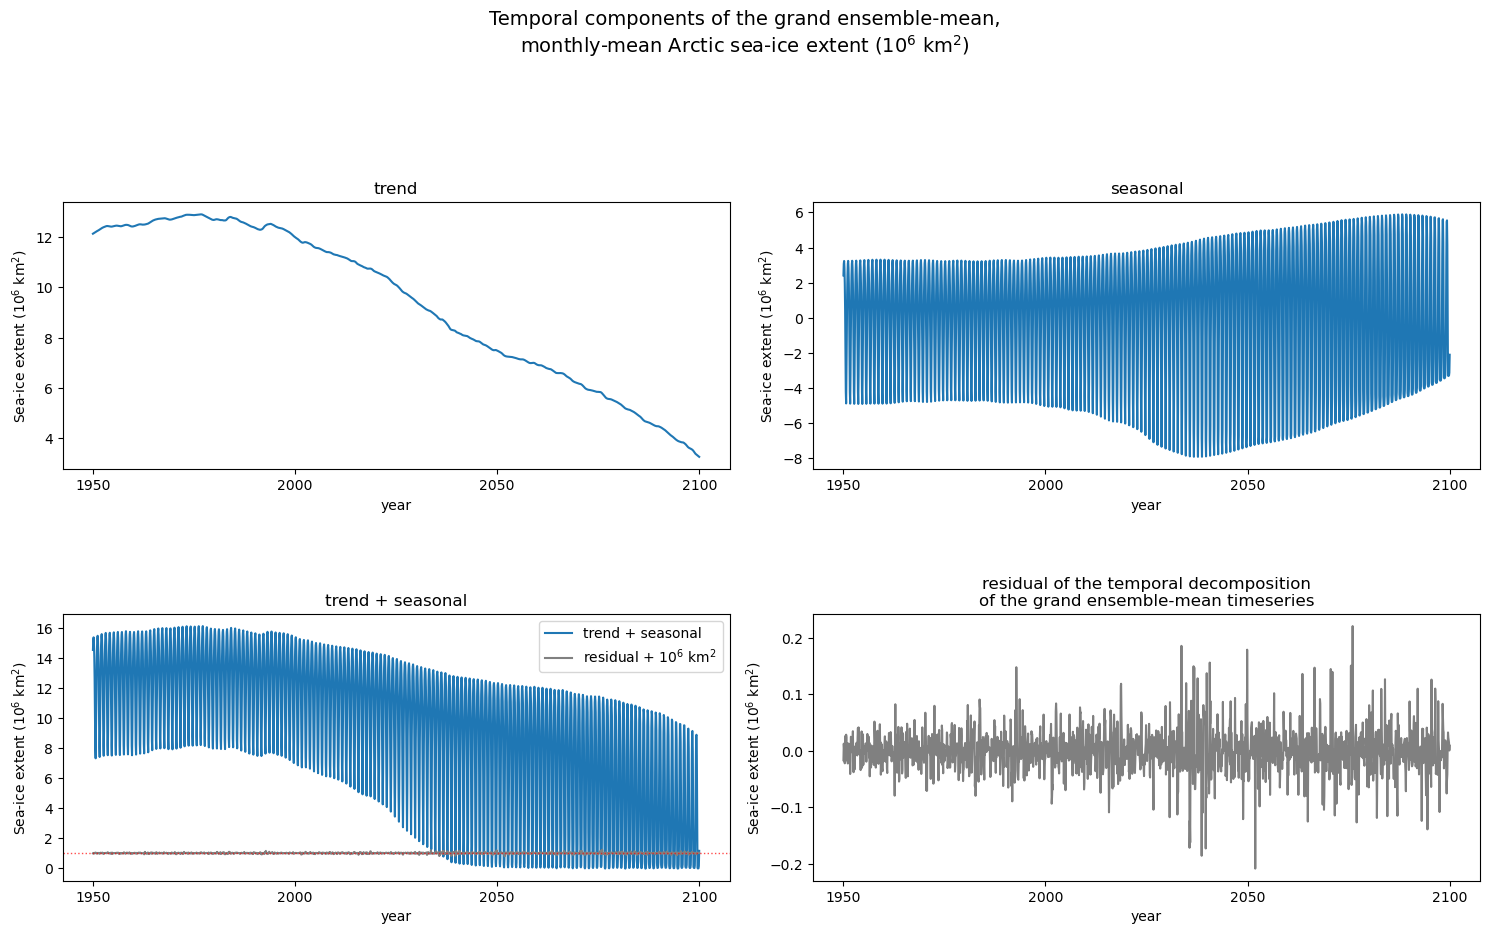

In [19]:
fig, axes = plot_STL_decomposition(g_jk_mean_STL_ds)

plt.show()

# Prepare the (j, k, time) data for sliding window, moving-block bootstrap (SWMBB) analysis 

In [25]:
# In this example, we subtract the trend and seasonal cycle (fitted to the ens. mean timeseries using STL) from each of the 40 members

g_original=da
g_detrended=da-trend
g_residual=g_original-trend-seasonal



### Plot a segment of the timeseries, showing the hierarchical structure for groups, j, and members, k.
### Select a parent group and child member for emphasis. 

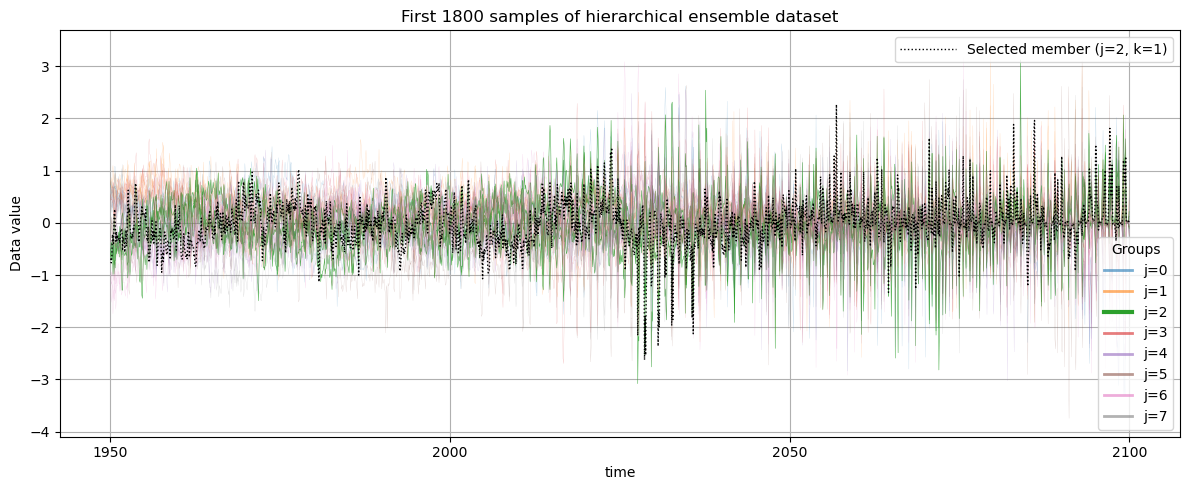

In [26]:

fig, ax = plot_groups_members(g_residual,
    ntimes=1800,
    jsel=2,
    ksel=1,
    j_dim="j",
    k_dim="k",
    t_dim="time",
)

plt.show()

### Compare across-ensemble variability and distribution, before and after preprocessing

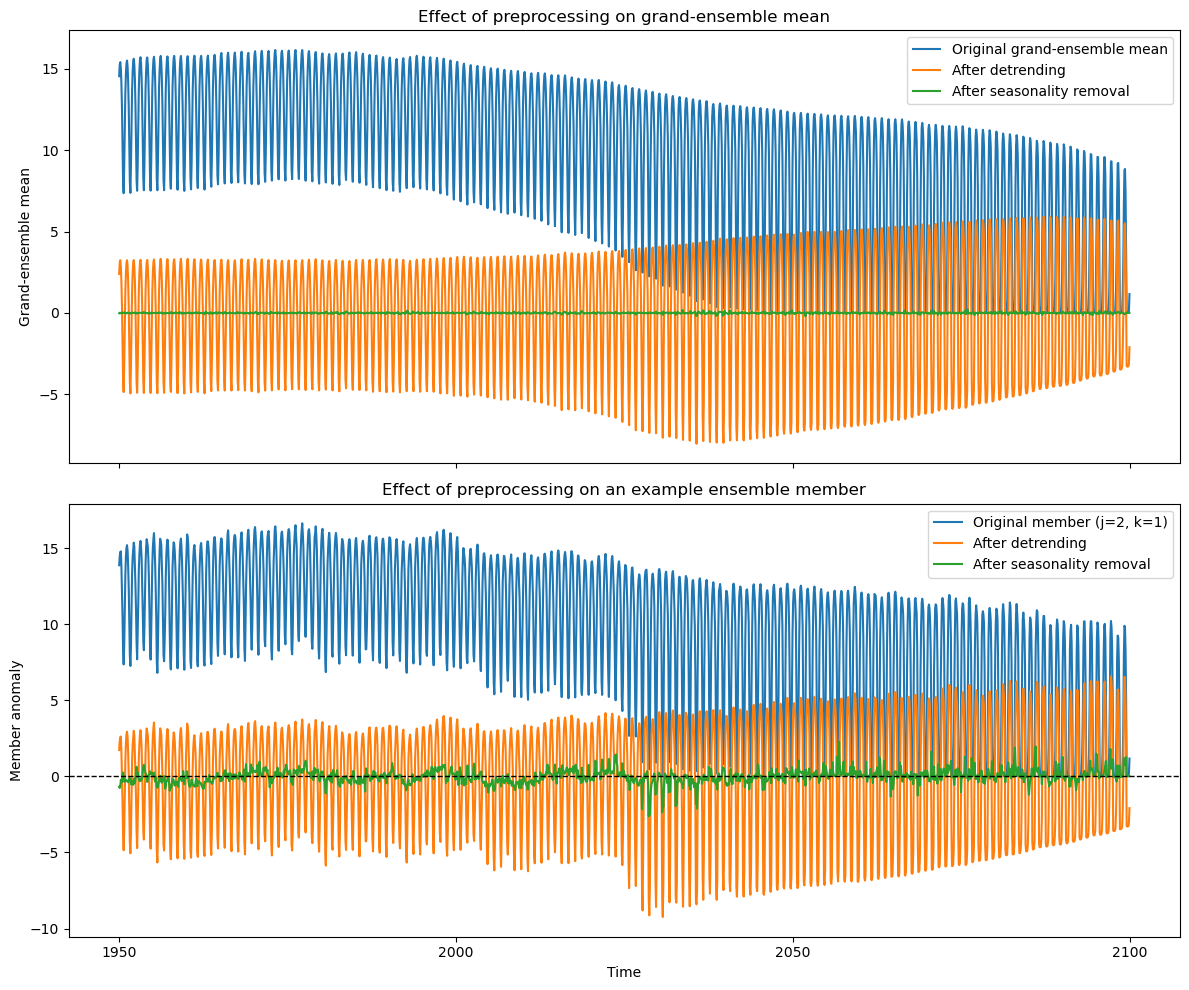

In [27]:
fig, ax = plot_preprocessing_components(
    g_original,
    g_detrended,
    g_residual,
    j_example=2,
    k_example=1,
    j_dim="j",
    k_dim="k",
    t_dim="time")

In [28]:
results = compute_preprocessing_variance_statistics(
    g_original,
    g_residual,
    j_dim="j",
    k_dim="k")

normalised_variance_original = results["ensemble_variance_original_norm"]
normalised_variance_residual = results["ensemble_variance_residual_norm"]

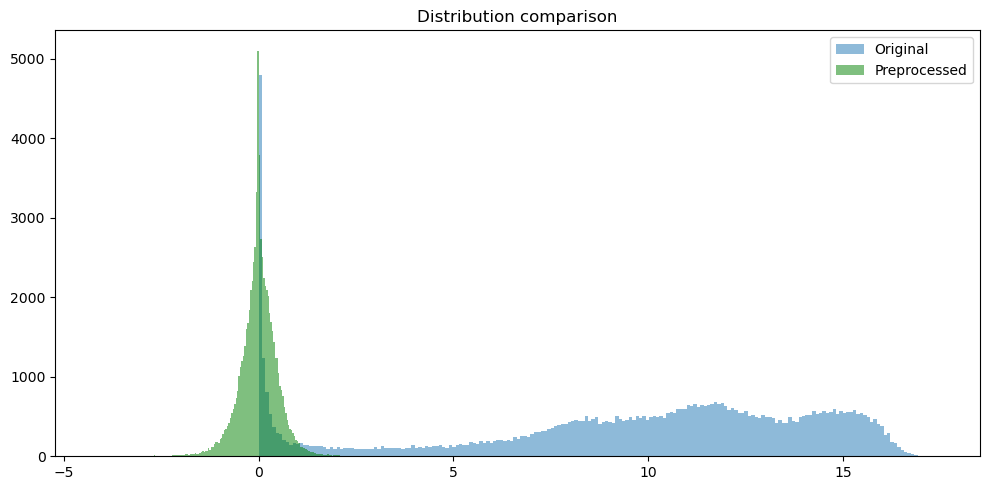

In [29]:
fig, ax = plot_distribution_comparison(g_original, g_residual, bins=200)

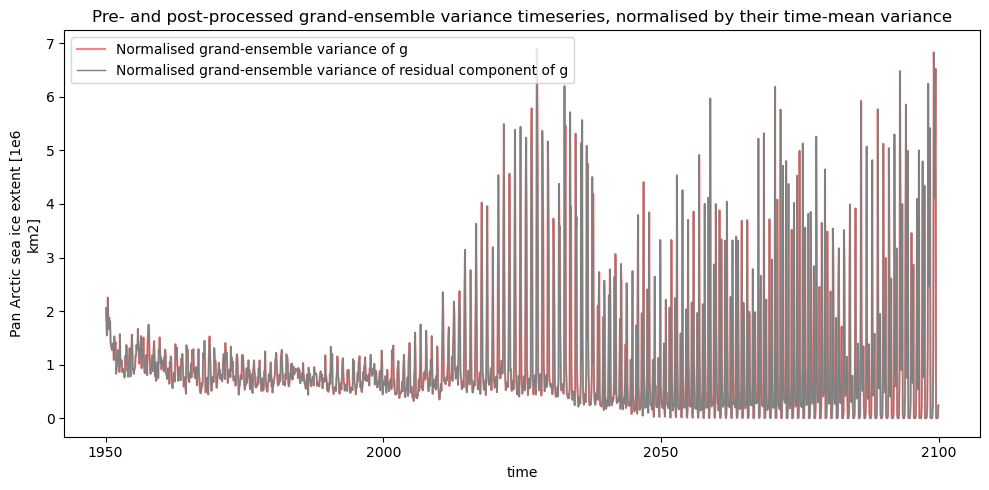

In [30]:
fig,ax = plot_normalised_variance(
    normalised_variance_original,
    normalised_variance_residual,
    t_dim="time")

# Calculate the sliding-window moving-block bootstrap analysis of variance over time, for the hierarchical ensemble structure 

In [31]:
g_preprocessed=g_residual  #these are equivalent (could be tidied in a future update)

### Estimate a suitable moving-block length (this can take a few minutes to calculate)

In [32]:
timescale_info = define_block_length(
    g_preprocessed,
    j_dim="j",
    k_dim="k",
    t_dim="t",
    persistence_factor=4, #usually choose a value between 3 and 5
    quantile=0.75,
)

block_length = timescale_info["block_length"]

print("Recommended block length:", block_length)
print(timescale_info)

Recommended block length: 60
{'acf_timescales': array([ 8, 14,  5,  9,  3,  8,  5,  4,  3,  3,  4,  3,  2, 15,  3, 31,  3,
        5,  3, 18, 14,  4,  6,  3, 14,  3, 52, 17,  3,  5, 17, 19, 18,  6,
        3, 15, 15,  6,  3,  3]), 'mi_timescales': array([ 3,  3,  4,  3,  3,  3,  4,  4,  3,  3,  3,  3,  3,  5,  3,  3,  3,
        4,  4, 14,  4,  4,  3,  3,  4,  3, 20, 14,  3,  3,  8,  6,  4,  3,
        3,  4,  5,  3,  3,  3]), 'representative_acf': 15, 'representative_mi': 4, 'dominant_persistence_scale': 15, 'block_length': 60}


### Compute statistics decomposition for one example block (e.g. statistics=ANOVA)

    Compute ANOVA-style variance decomposition statistics for a block.
    
    Motivated by: 
    Hodson, D. L. R. and R. T. Sutton (2008). doi: 10.1007/s00382-008-0372-z.
    Hawkins, E. and R. T. Sutton (2009). doi: 10.1175/2009BAMS2607.1.
    Deser, C. et al. (2025). doi: 10.1007/s00382-024-07553-z
    
    The decomposition separates the signal into:
    - mu = time-mean of grand ensemble-mean
    - alpha = time variation of grand ensemble-mean w.r.t. mu
    - beta = group bias w.r.t. mu
    - gamma = time variation of unbiased group-mean
    - epsilon = internal variability

    If the input data has been preprocessed, e.g. using STL to remove trend and seasonal
    components, it is common to use that residual as the input, i.e.  
    
$g_{residual}=g_{original}-g_{trend}-g_{seasonal}$.

Then we subsample in time to define a block, $g_{block}(j,k,t)\subset g_{residual}(j,k,t)$, which is decomposed as:

$g_{block}(j,k,t)=\mu+\alpha(t)+\beta(j)+\gamma(j,t)+\epsilon(j,k,t)$.

    Note that each member has a timeseries that can be expressed as the above decomposition, but also that
    if we want to consider the components of *temporal* variance, only three terms contribute to the total *temporal* variance
    *of the input data* (remember that the trend and seasonal components also contribute to overall temporal variability):

$\sigma^2_{total} = \sigma^2_\alpha + \sigma^2_\gamma (j) + \sigma^2_\epsilon (j,k)$

    

In [59]:
g_block = g_preprocessed.isel(time=slice(0, block_length))

stats = compute_block_statistics_anova(
    g_block,
    j_dim="j",
    k_dim="k",
    t_dim="time",
)

print(stats)

{'mu': <xarray.DataArray ()> Size: 8B
array(0.00067658)
Coordinates:
    siconc_threshold  float32 4B 0.15
Attributes:
    long_name:      Pan Arctic sea ice extent
    standard_name:  sea_ice_extent
    units:          1e6 km2, 'alpha_mean': <xarray.DataArray ()> Size: 8B
array(-5.78241159e-20)
Coordinates:
    siconc_threshold  float32 4B 0.15
Attributes:
    long_name:      Pan Arctic sea ice extent
    standard_name:  sea_ice_extent
    units:          1e6 km2, 'alpha_var': <xarray.DataArray ()> Size: 8B
array(0.00039616)
Coordinates:
    siconc_threshold  float32 4B 0.15
Attributes:
    long_name:      Pan Arctic sea ice extent
    standard_name:  sea_ice_extent
    units:          1e6 km2, 'gamma_mean': <xarray.DataArray (j: 8)> Size: 64B
array([-8.32667268e-18, -2.05275611e-18,  1.06396373e-17, -2.77555756e-18,
       -1.48029737e-17,  1.66533454e-17,  6.47630098e-18, -4.90348503e-17])
Coordinates:
  * j                 (j) int64 64B 0 1 2 3 4 5 6 7
    siconc_threshold  float32

### Check the closure for this example block (single time segment) for each of the members

In [68]:


for j in range(8):
    for k in range(5):

        closure_error = (
            stats["alpha_var"]
            + stats["gamma_var"].sel(j=j)
            + stats["epsilon_var"].sel(j=j, k=k)
            - stats["total_var"].sel(j=j, k=k)
        )

        max_abs_error = float(np.abs(closure_error).max())

        #mean_abs_error = float(np.abs(closure_error).mean())

        print(
            f"(j={j}, k={k}) : "
            f"max |closure error| = {max_abs_error:.6f}, "
            #f"mean |closure error| = {mean_abs_error:.6f}"
        )

(j=0, k=0) : max |closure error| = 0.001079, 
(j=0, k=1) : max |closure error| = 0.014725, 
(j=0, k=2) : max |closure error| = 0.012958, 
(j=0, k=3) : max |closure error| = 0.015608, 
(j=0, k=4) : max |closure error| = 0.010468, 
(j=1, k=0) : max |closure error| = 0.007627, 
(j=1, k=1) : max |closure error| = 0.001767, 
(j=1, k=2) : max |closure error| = 0.005882, 
(j=1, k=3) : max |closure error| = 0.008528, 
(j=1, k=4) : max |closure error| = 0.006904, 
(j=2, k=0) : max |closure error| = 0.027021, 
(j=2, k=1) : max |closure error| = 0.033139, 
(j=2, k=2) : max |closure error| = 0.042522, 
(j=2, k=3) : max |closure error| = 0.015080, 
(j=2, k=4) : max |closure error| = 0.026572, 
(j=3, k=0) : max |closure error| = 0.019472, 
(j=3, k=1) : max |closure error| = 0.013776, 
(j=3, k=2) : max |closure error| = 0.000483, 
(j=3, k=3) : max |closure error| = 0.013044, 
(j=3, k=4) : max |closure error| = 0.011316, 
(j=4, k=0) : max |closure error| = 0.013079, 
(j=4, k=1) : max |closure error| =

### .... and globally, across all members

In [69]:
closure_error_global = (
    stats["alpha_var"]
    + stats["gamma_var"].mean(dim="j")
    + stats["epsilon_var"].mean(dim=("j","k"))
    - stats["total_var"].mean(dim=("j","k"))
)
print(float(np.abs(closure_error_global).max()))


0.0


## Now we can compute the sliding window, moving-block bootstrap ensemble analysis of statistics (here, statistics=ANOVA)

In [95]:
# Choice of length of the sliding window is important!
#   - if it is too short, there will not be many independent overlapping bootstrap blocks available
#     (if the window width is w and the block length is b, there are w-b+1.)
#   - if it is too long, then high-frequency dynamical information could be lost to smoothing.
#   - the data sampling period and the overall length of the full timeseries affect this choice too.

# The block_length was estimated by the earlier call of define_block_length
# and the sliding window_length is defined here.  window_length must be > block_length.

window_length = 120 # This is 10 years for monthly data

results = sliding_window_MBB_ensemble_analysis(
    g_preprocessed,    
    j_dim="j",
    k_dim="k",
    t_dim="time",
    window_length=window_length,
    bootstrap=True,
    n_boot=200, #use 200 or larger for production calculation!
    block_length=block_length,
    random_seed=123,
    store_bootstrap_samples=True
    )

print(results)


<xarray.Dataset> Size: 897MB
Dimensions:                (time: 1800, j: 8, k: 5, boot: 200)
Coordinates:
  * time                   (time) object 14kB 1950-01-21 00:00:00 ... 2099-12...
  * j                      (j) int64 64B 0 1 2 3 4 5 6 7
  * k                      (k) int64 40B 0 1 2 3 4
  * boot                   (boot) int64 2kB 0 1 2 3 4 5 ... 195 196 197 198 199
Data variables: (12/52)
    mu                     (time) float64 14kB 0.0007284 ... -0.0004626
    alpha_mean             (time) float64 14kB 1.322e-18 1.791e-18 ... 3.413e-19
    alpha_var              (time) float64 14kB 0.0003897 0.0003838 ... 0.001842
    gamma_mean             (time, j) float64 115kB 1.82e-18 ... -3.263e-18
    gamma_var              (time, j) float64 115kB 0.02862 0.0136 ... 0.05931
    epsilon_mean           (time, j, k) float64 576kB 0.01861 ... -0.07871
    ...                     ...
    F_epsilon_boot         (time, boot, j, k) float64 115MB 0.5799 ... 0.638
    F_epsilon_ci_lower     (time

# Plot some results....

## Q1. Are there times when memory of macro initial conditions (i.e. associated with parent group, with index j) can be attributed to a potentially predictable change?

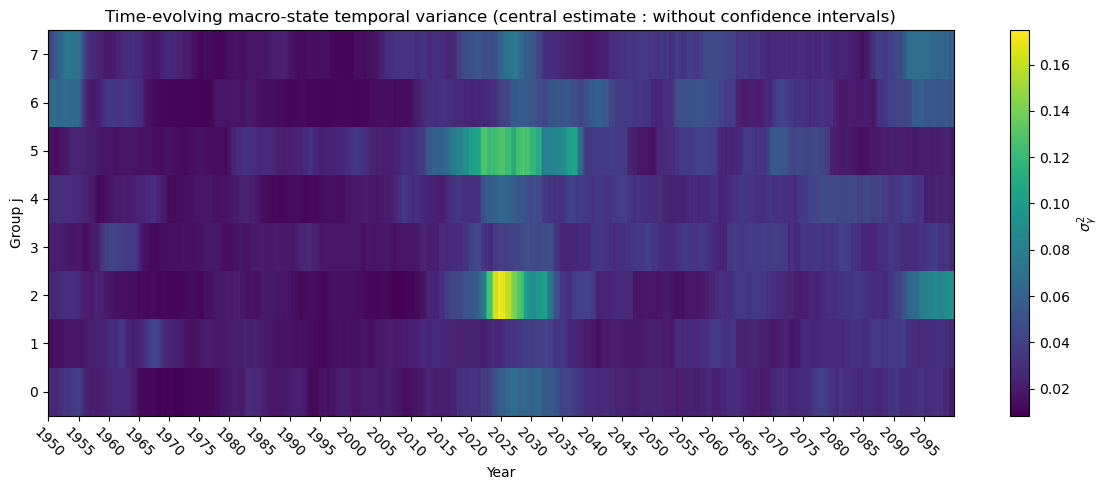

In [112]:
# Plot the central estimate of each group (j=macro-state) component of temporal variance over the sliding window

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))

im = results["gamma_var"].transpose("j", "time").plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": r"$\sigma_\gamma^2$"},
)




# ----------------------------------------------------------
# Labels/titles
# ----------------------------------------------------------
ax.set_ylabel("Group j")

ax.set_xlabel("Year")

ax.set_title(
    "Time-evolving macro-state temporal variance "
    "(central estimate : without confidence intervals)"
)


# ----------------------------------------------------------
# Tick every 5 years (= 60 monthly samples)
# ----------------------------------------------------------
tick_idx = np.arange(0, len(results["time"]), 60)

tick_times = results["time"].values[tick_idx]

ax.set_xticks(tick_times)

ax.set_xticklabels(
    [str(t.year) for t in tick_times],
    rotation=-45,
)
plt.tight_layout()
plt.show()

### Plot the central estimate of each group (j= macro-state) component of signal to noise ratio, $\sigma_\gamma^2/\sigma_\epsilon^2$, based on temporal variance over the sliding window
### with confidence intervals on the SNR being estimated by propagating the (nonlinear) ratio of variance through the MBB.

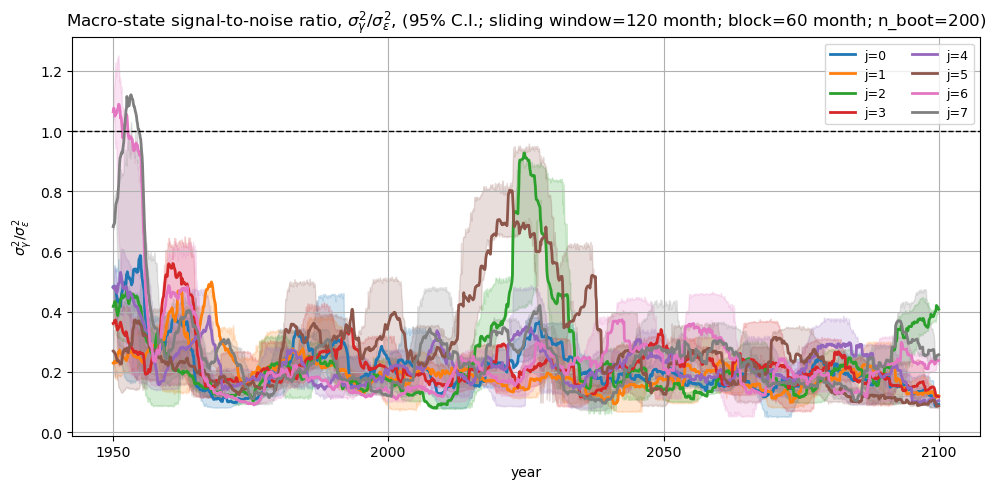

In [119]:
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

cmap = plt.get_cmap("tab10")

# ----------------------------------------------------------
# Ensemble-mean epsilon bootstrap distribution
# Shape:
#   (time, boot)
# ----------------------------------------------------------
epsilon_boot = (
    results["epsilon_var_boot"]
    .mean(dim=("j", "k"))
)

for j in results["j"].values:

    color = cmap(j)

    # ------------------------------------------------------
    # Central estimate
    # ------------------------------------------------------
    gamma_central = (
        results["gamma_var"]
        .sel(j=j)
    )

    epsilon_central = (
        results["epsilon_var"]
        .mean(dim=("j", "k"))
    )

    snr = (
        gamma_central
        / epsilon_central
    )

    # ------------------------------------------------------
    # Bootstrap SNR distribution
    #
    # Shape:
    #   (time, boot)
    # ------------------------------------------------------
    gamma_boot = (
        results["gamma_var_boot"]
        .sel(j=j)
    )

    snr_boot = (
        gamma_boot
        / epsilon_boot
    )

    # ------------------------------------------------------
    # Bootstrap confidence intervals
    # ------------------------------------------------------
    snr_lower = (
        snr_boot
        .quantile(0.025, dim="boot")
    )

    snr_upper = (
        snr_boot
        .quantile(0.975, dim="boot")
    )

    # ------------------------------------------------------
    # Plot central estimate
    # ------------------------------------------------------
    ax.plot(
        results["time"].values,
        snr.values,
        color=color,
        linewidth=2,
        label=f"j={j}",
    )

    # ------------------------------------------------------
    # Plot bootstrap CI envelope
    # ------------------------------------------------------
    ax.fill_between(
        results["time"].values,
        snr_lower.values,
        snr_upper.values,
        color=color,
        alpha=0.2,
    )

# ----------------------------------------------------------
# Reference line
# ----------------------------------------------------------
ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1,
)


ax.set_ylabel(
    r"$\sigma_\gamma^2 / \sigma_\epsilon^2$"
)

ax.set_xlabel("year")

ax.set_title(
    r"Macro-state signal-to-noise ratio, $\sigma_\gamma^2/ \sigma_\epsilon^2$, (95% C.I.; sliding window=120 month; block=60 month; n_boot=200)"
)

ax.grid(True)

ax.legend(
    ncol=2,
    fontsize=9,
)

plt.tight_layout()

plt.show()

### Plot the central estimate of each group (j= macro-state) component of fraction of predictable variance, $(\sigma_\alpha^2+\sigma_\gamma^2)/\sigma_{total}^2$, based on temporal variance over the sliding window
### with confidence intervals on the FPV being estimated by propagating the (nonlinear) ratio of variance through the MBB.  N.B. $\sigma_{total}^2$ is that of the **SWMBB input data, i.e. after any preprocessing**.

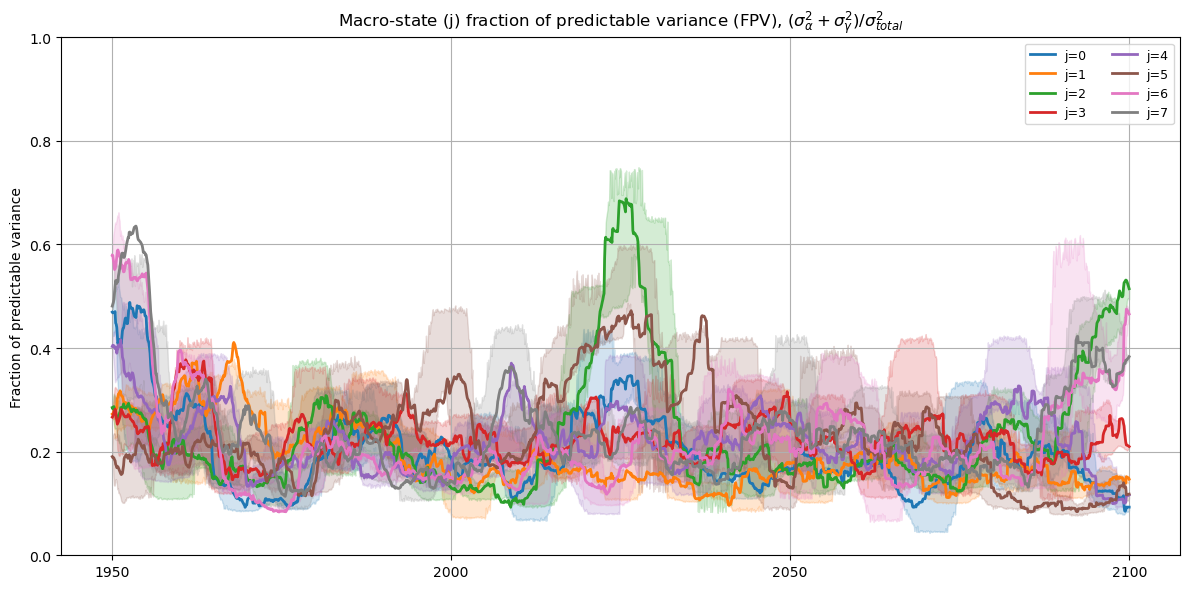

In [118]:
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Mean over members only
# Retain separate j-groups
# ----------------------------------------------------------
F_pred = (
    results["F_pred"]
    .mean(dim="k")
)

# ----------------------------------------------------------
# Bootstrap confidence intervals
# ----------------------------------------------------------
F_pred_lower = (
    results["F_pred_boot"]
    .mean(dim="k")
    .quantile(0.025, dim="boot")
)

F_pred_upper = (
    results["F_pred_boot"]
    .mean(dim="k")
    .quantile(0.975, dim="boot")
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

cmap = plt.get_cmap("tab10")

for j in results["j"].values:

    color = cmap(j)

    # Central estimate
    ax.plot(
        results["time"].values,
        F_pred.sel(j=j).values,
        color=color,
        linewidth=2,
        label=f"j={j}",
    )

    # Confidence interval envelope
    ax.fill_between(
        results["time"].values,
        F_pred_lower.sel(j=j).values,
        F_pred_upper.sel(j=j).values,
        color=color,
        alpha=0.2,
    )

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
ax.set_ylim(0, 1)

ax.set_ylabel(
    "Fraction of predictable variance"
)

ax.set_title(
    r"Macro-state (j) fraction of predictable variance (FPV), $(\sigma_\alpha^2+\sigma_\gamma^2)/\sigma_{total}^2$"
)

ax.grid(True)

ax.legend(
    ncol=2,
    fontsize=9,
)

plt.tight_layout()
plt.show()

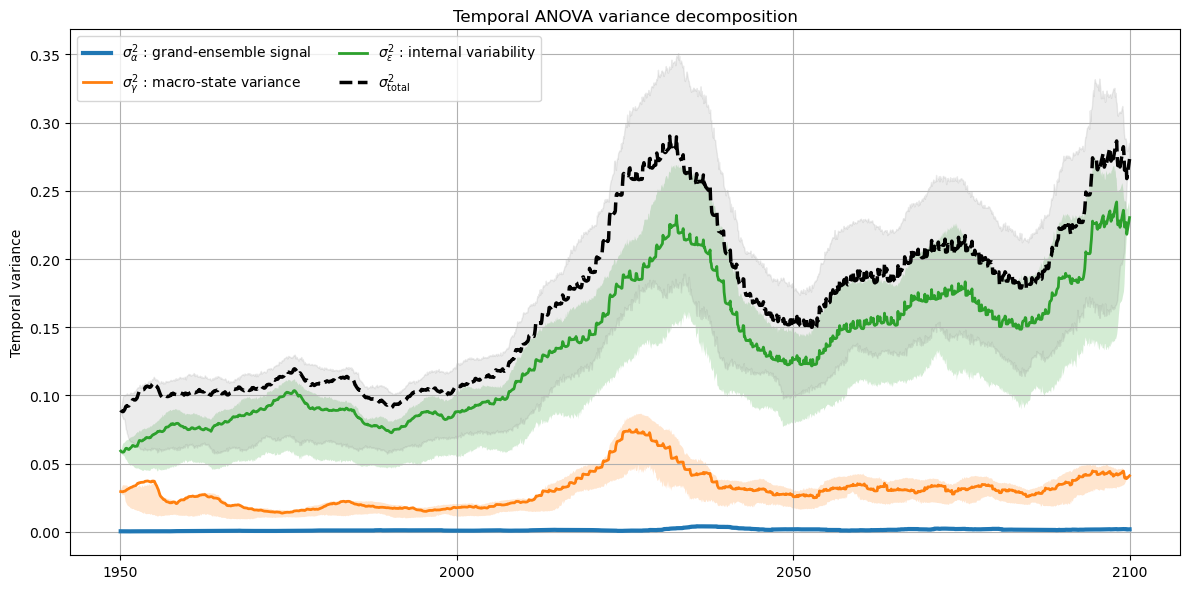

In [120]:
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Central estimates
# ----------------------------------------------------------
alpha = results["alpha_var"]

gamma = (
    results["gamma_var"]
    .mean(dim="j")
)

epsilon = (
    results["epsilon_var"]
    .mean(dim=("j", "k"))
)

total = (
    results["total_var"]
    .mean(dim=("j", "k"))
)

# ----------------------------------------------------------
# Confidence intervals
# ----------------------------------------------------------
alpha_lower = results["alpha_var_ci_lower"]
alpha_upper = results["alpha_var_ci_upper"]

gamma_lower = (
    results["gamma_var_ci_lower"]
    .mean(dim="j")
)

gamma_upper = (
    results["gamma_var_ci_upper"]
    .mean(dim="j")
)

epsilon_lower = (
    results["epsilon_var_ci_lower"]
    .mean(dim=("j", "k"))
)

epsilon_upper = (
    results["epsilon_var_ci_upper"]
    .mean(dim=("j", "k"))
)

total_lower = (
    results["total_var_ci_lower"]
    .mean(dim=("j", "k"))
)

total_upper = (
    results["total_var_ci_upper"]
    .mean(dim=("j", "k"))
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# ----------------------------------------------------------
# alpha variance
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    alpha.values,
    linewidth=3,
    label=r"$\sigma_\alpha^2$ : grand-ensemble signal",
)

ax.fill_between(
    results["time"].values,
    alpha_lower.values,
    alpha_upper.values,
    alpha=0.2,
)

# ----------------------------------------------------------
# gamma variance
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    gamma.values,
    linewidth=2,
    label=r"$\sigma_\gamma^2$ : macro-state variance",
)

ax.fill_between(
    results["time"].values,
    gamma_lower.values,
    gamma_upper.values,
    alpha=0.2,
)

# ----------------------------------------------------------
# epsilon variance
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    epsilon.values,
    linewidth=2,
    label=r"$\sigma_\epsilon^2$ : internal variability",
)

ax.fill_between(
    results["time"].values,
    epsilon_lower.values,
    epsilon_upper.values,
    alpha=0.2,
)

# ----------------------------------------------------------
# total variance
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    total.values,
    color="black",
    linewidth=2.5,
    linestyle="--",
    label=r"$\sigma_{\mathrm{total}}^2$",
)

ax.fill_between(
    results["time"].values,
    total_lower.values,
    total_upper.values,
    color="grey",
    alpha=0.15,
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
ax.set_ylabel("Temporal variance")

ax.set_title(
    r"Temporal ANOVA variance decomposition"
)

ax.grid(True)

ax.legend(
    ncol=2,
    fontsize=10,
)

plt.tight_layout()
plt.show()

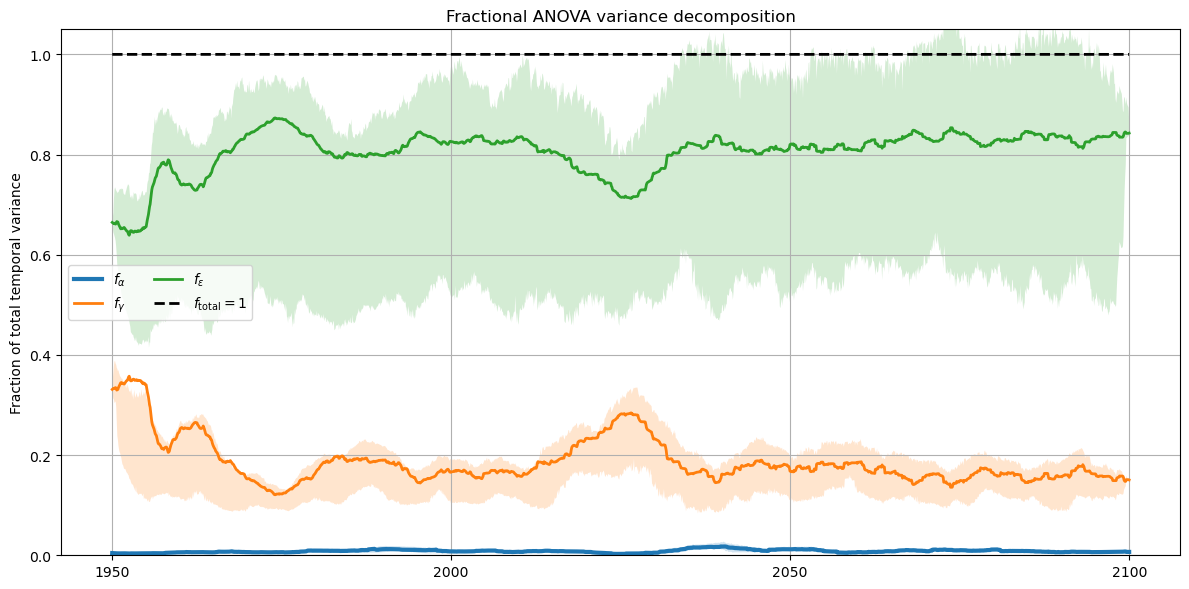

In [121]:
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Mean total variance
# ----------------------------------------------------------
total = (
    results["total_var"]
    .mean(dim=("j", "k"))
)

# ----------------------------------------------------------
# Fractional variance components
# ----------------------------------------------------------
f_alpha = (
    results["alpha_var"]
    / total
)

f_gamma = (
    results["gamma_var"]
    .mean(dim="j")
    / total
)

f_epsilon = (
    results["epsilon_var"]
    .mean(dim=("j", "k"))
    / total
)

# ----------------------------------------------------------
# Confidence intervals
# ----------------------------------------------------------
f_alpha_lower = (
    results["alpha_var_ci_lower"]
    / total
)

f_alpha_upper = (
    results["alpha_var_ci_upper"]
    / total
)

f_gamma_lower = (
    results["gamma_var_ci_lower"]
    .mean(dim="j")
    / total
)

f_gamma_upper = (
    results["gamma_var_ci_upper"]
    .mean(dim="j")
    / total
)

f_epsilon_lower = (
    results["epsilon_var_ci_lower"]
    .mean(dim=("j", "k"))
    / total
)

f_epsilon_upper = (
    results["epsilon_var_ci_upper"]
    .mean(dim=("j", "k"))
    / total
)

# ----------------------------------------------------------
# Total fractional variance (=1)
# ----------------------------------------------------------
f_total = total / total

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# ----------------------------------------------------------
# alpha fraction
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    f_alpha.values,
    linewidth=3,
    label=r"$f_\alpha$",
)

ax.fill_between(
    results["time"].values,
    f_alpha_lower.values,
    f_alpha_upper.values,
    alpha=0.2,
)

# ----------------------------------------------------------
# gamma fraction
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    f_gamma.values,
    linewidth=2,
    label=r"$f_\gamma$",
)

ax.fill_between(
    results["time"].values,
    f_gamma_lower.values,
    f_gamma_upper.values,
    alpha=0.2,
)

# ----------------------------------------------------------
# epsilon fraction
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    f_epsilon.values,
    linewidth=2,
    label=r"$f_\epsilon$",
)

ax.fill_between(
    results["time"].values,
    f_epsilon_lower.values,
    f_epsilon_upper.values,
    alpha=0.2,
)

# ----------------------------------------------------------
# Total variance fraction
# ----------------------------------------------------------
ax.plot(
    results["time"].values,
    f_total.values,
    color="black",
    linewidth=2,
    linestyle="--",
    label=r"$f_{\mathrm{total}} = 1$",
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
ax.set_ylim(0, 1.05)

ax.set_ylabel(
    "Fraction of total temporal variance"
)

ax.set_title(
    r"Fractional ANOVA variance decomposition"
)

ax.grid(True)

ax.legend(
    ncol=2,
    fontsize=10,
)

plt.tight_layout()
plt.show()

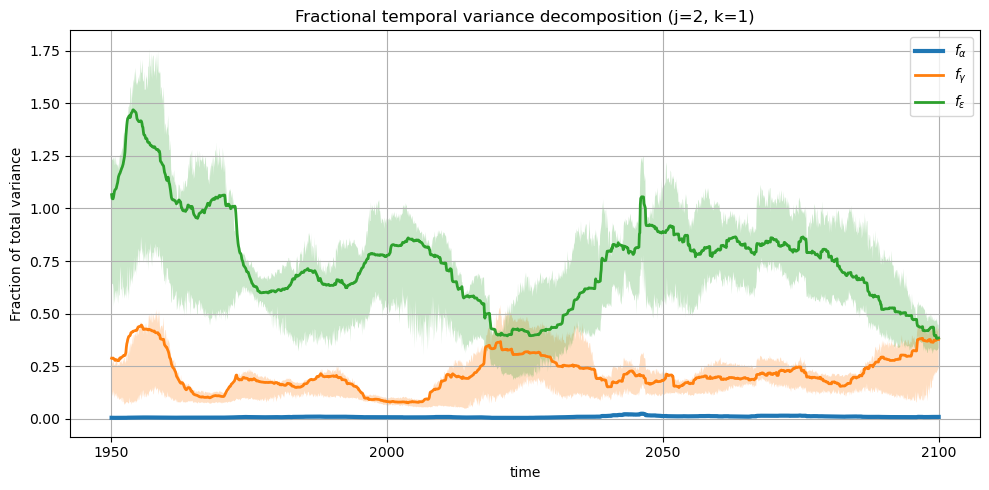

In [53]:
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Select group/member
# ----------------------------------------------------------
j_sel = 2
k_sel = 1

# ----------------------------------------------------------
# Total variance for selected member
# ----------------------------------------------------------
total = results["total_var"].sel(
    j=j_sel,
    k=k_sel,
)

# ----------------------------------------------------------
# Central estimates
# ----------------------------------------------------------
f_alpha = results["alpha_var"] / total

f_gamma = (
    results["gamma_var"].sel(j=j_sel)
    / total
)

f_epsilon = (
    results["epsilon_var"].sel(
        j=j_sel,
        k=k_sel,
    )
    / total
)

# ----------------------------------------------------------
# Confidence intervals
# ----------------------------------------------------------

# alpha
f_alpha_lower = (
    results["alpha_var_ci_lower"]
    / total
)

f_alpha_upper = (
    results["alpha_var_ci_upper"]
    / total
)

# gamma
f_gamma_lower = (
    results["gamma_var_ci_lower"]
    .sel(j=j_sel)
    / total
)

f_gamma_upper = (
    results["gamma_var_ci_upper"]
    .sel(j=j_sel)
    / total
)

# epsilon
f_epsilon_lower = (
    results["epsilon_var_ci_lower"]
    .sel(j=j_sel, k=k_sel)
    / total
)

f_epsilon_upper = (
    results["epsilon_var_ci_upper"]
    .sel(j=j_sel, k=k_sel)
    / total
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# ----------------------------------------------------------
# f_alpha
# ----------------------------------------------------------
f_alpha.plot(
    ax=ax,
    linewidth=3,
    label=r"$f_\alpha$",
)

ax.fill_between(
    results["time"].values,
    f_alpha_lower.values,
    f_alpha_upper.values,
    alpha=0.25,
)

# ----------------------------------------------------------
# f_gamma
# ----------------------------------------------------------
f_gamma.plot(
    ax=ax,
    linewidth=2,
    label=r"$f_\gamma$",
)

ax.fill_between(
    results["time"].values,
    f_gamma_lower.values,
    f_gamma_upper.values,
    alpha=0.25,
)

# ----------------------------------------------------------
# f_epsilon
# ----------------------------------------------------------
f_epsilon.plot(
    ax=ax,
    linewidth=2,
    label=r"$f_\epsilon$",
)

ax.fill_between(
    results["time"].values,
    f_epsilon_lower.values,
    f_epsilon_upper.values,
    alpha=0.25,
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
#ax.set_ylim(0, 1)

ax.set_ylabel("Fraction of total variance")

ax.set_title(
    rf"Fractional temporal variance decomposition "
    rf"(j={j_sel}, k={k_sel})"
)

ax.legend()

ax.grid(True)

plt.tight_layout()

plt.show()

In [122]:
closure_error = (
    results["alpha_var"]
    + results["gamma_var"].sel(j=2)
    + results["epsilon_var"].sel(j=2, k=1)
    - results["total_var"].sel(j=2, k=1)
)

print(float(np.abs(closure_error).max()))

0.1901352463703263


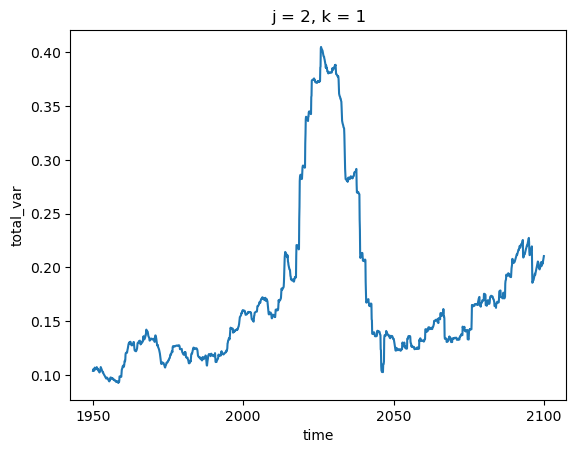

In [50]:
results["total_var"].sel(j=2, k=1).plot()

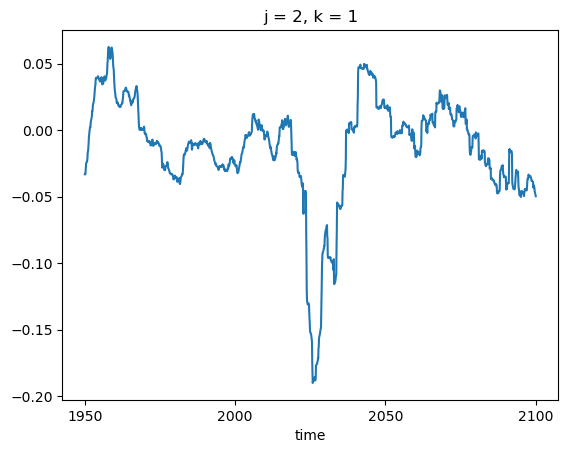

In [123]:
closure_error.plot()

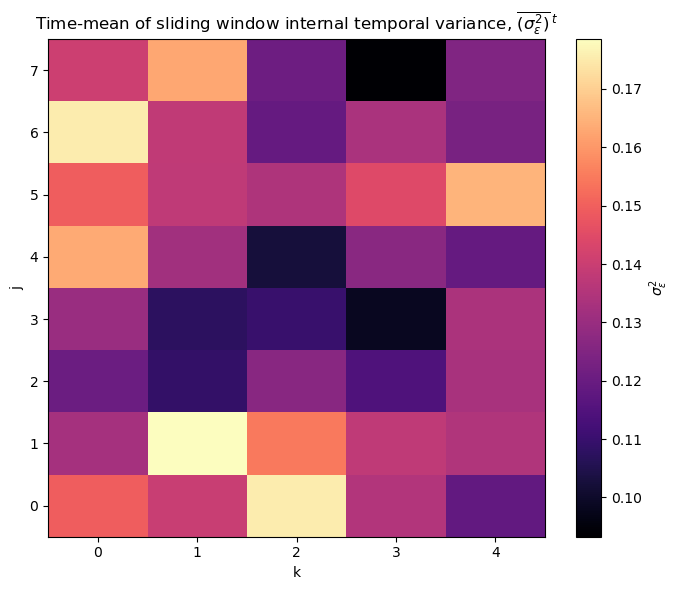

In [132]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

results["epsilon_var"].mean(dim="time").plot(
    ax=ax,
    cmap="magma",
    cbar_kwargs={
        "label": r"$\sigma_\epsilon^2$"
    },
)

ax.set_title(
    r"Time-mean of sliding window internal temporal variance, $\overline{(\sigma_\epsilon^2)}^{\,t}$"
)

plt.tight_layout()
plt.show()

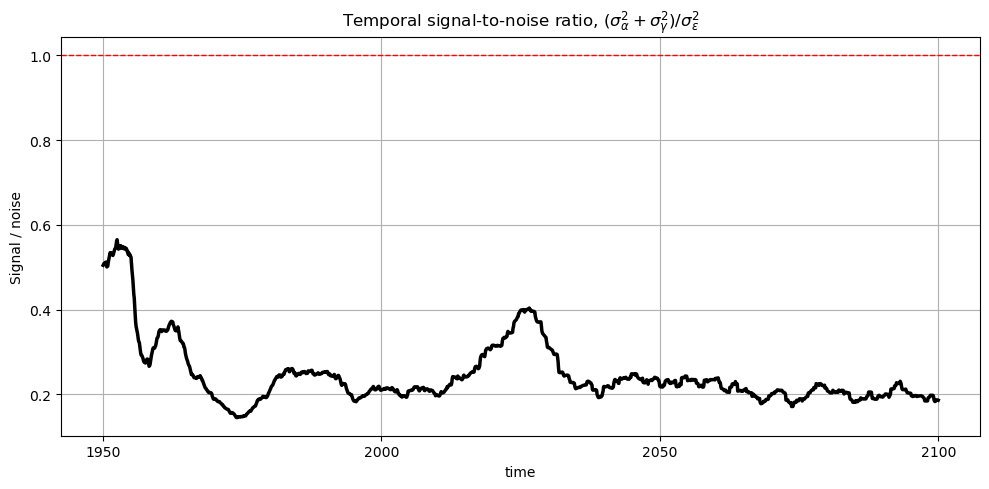

In [125]:
import matplotlib.pyplot as plt

signal = (
    results["alpha_var"]
    + results["gamma_var"].mean(dim="j")
)

noise = results["epsilon_var"].mean(dim=("j", "k"))

snr = signal / noise

fig, ax = plt.subplots(figsize=(10, 5))

snr.plot(
    ax=ax,
    linewidth=2.5,
    color="black",
)

ax.axhline(
    1.0,
    color="red",
    linestyle="--",
    linewidth=1,
)

ax.set_ylabel("Signal / noise")

ax.set_title(
    r"Temporal signal-to-noise ratio, $(\sigma_\alpha^2+\sigma_\gamma^2)/\sigma_\epsilon^2$"
)

ax.grid(True)

plt.tight_layout()
plt.show()

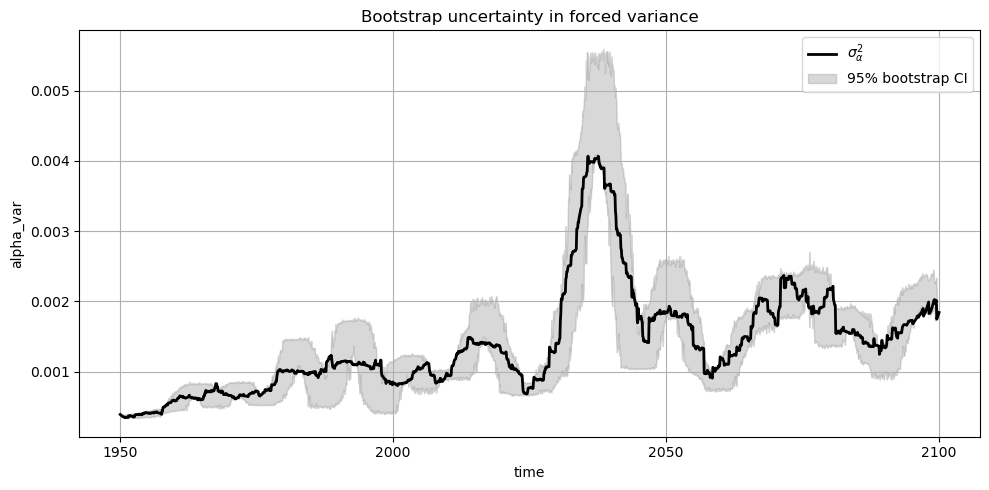

In [126]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

central = results["alpha_var"]

lower = results["alpha_var_ci_lower"]
upper = results["alpha_var_ci_upper"]

central.plot(
    ax=ax,
    color="black",
    linewidth=2,
    label=r"$\sigma_\alpha^2$",
)

ax.fill_between(
    results["time"].values,
    lower.values,
    upper.values,
    color="grey",
    alpha=0.3,
    label="95% bootstrap CI",
)

ax.set_title(
    "Bootstrap uncertainty in forced variance"
)

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

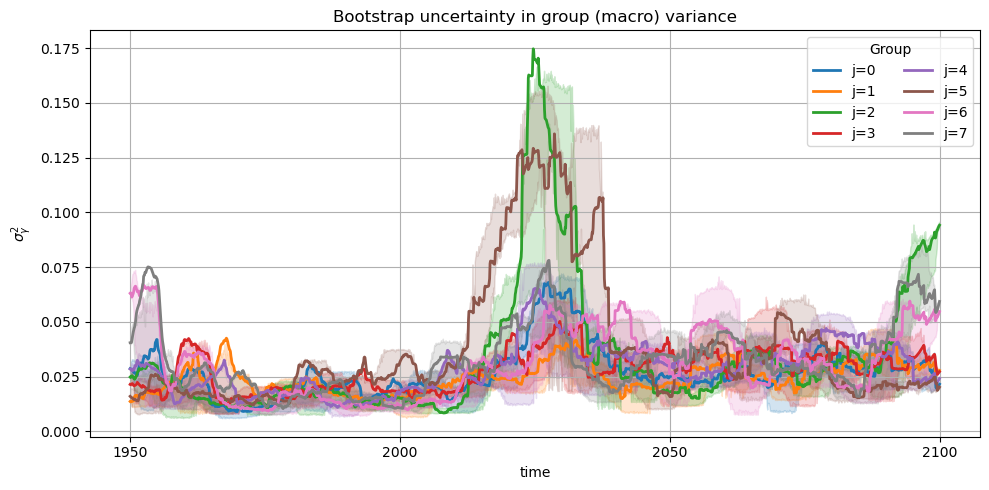

In [127]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Colormap for groups
cmap = plt.get_cmap("tab10")

# Loop over groups
for j in results["j"].values:

    color = cmap(j)

    central = results["gamma_var"].sel(j=j)

    lower = results["gamma_var_ci_lower"].sel(j=j)

    upper = results["gamma_var_ci_upper"].sel(j=j)

    # Central estimate
    central.plot(
        ax=ax,
        color=color,
        linewidth=2,
        label=f"j={j}",
    )

    time = central["time"].values
    
    # Confidence interval
    ax.fill_between(
    time,
    lower.values,
    upper.values,
    color=color,
    alpha=0.2)

ax.set_title(
    "Bootstrap uncertainty in group (macro) variance"
)

ax.set_ylabel(r"$\sigma_\gamma^2$")

ax.grid(True)

ax.legend(
    title="Group",
    ncol=2,
)

plt.tight_layout()

plt.show()

In [128]:
lower

<xarray.DataArray 'gamma_var_ci_lower' (time: 1800)> Size: 14kB
array([0.04016294, 0.03975116, 0.04012626, ..., 0.05751687, 0.05838642,
       0.05931005], shape=(1800,))
Coordinates:
  * time     (time) object 14kB 1950-01-21 00:00:00 ... 2099-12-21 00:00:00
    j        int64 8B 7

In [17]:
SNR_j = results["gamma_var"] / results["epsilon_var"].mean(dim="k")

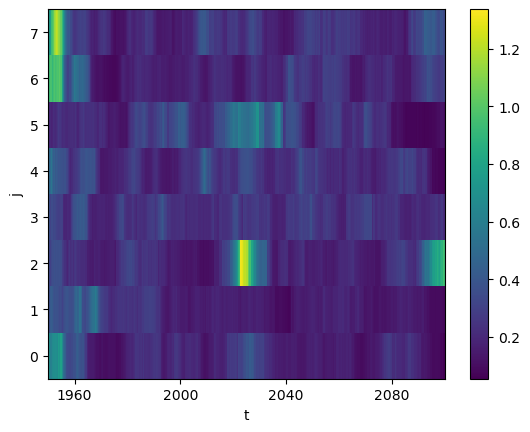

In [18]:
SNR_j.T.plot()

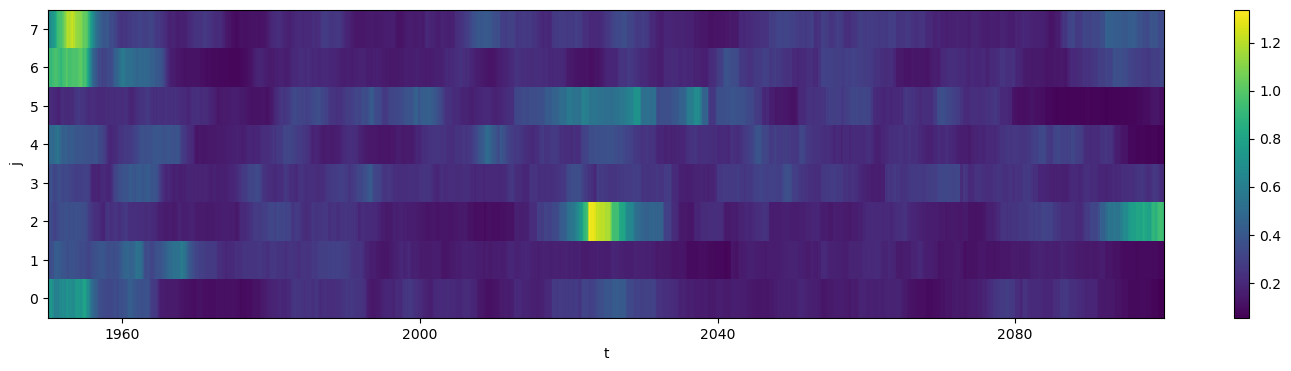

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 4))  # (width, height) in inches
plt.title("Signal to noise ratio of each macro in CANARI LE (monthly-mean SIE)")
SNR_j.T.plot()

In [20]:
F_pred = (
    results["alpha_var"]
    + results["gamma_var"].mean(dim="j")
) / results["total_var"].mean(dim=("j", "k"))

In [20]:
F_alpha = (
    results["alpha_var"]
) / results["total_var"].mean(dim=("j", "k"))

In [24]:
F_gamma = (
     results["gamma_var"].mean(dim="j")
) / results["total_var"].mean(dim=("j", "k"))

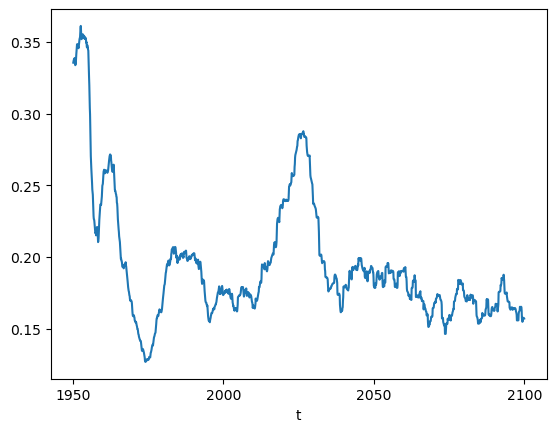

In [17]:
F_pred.plot()

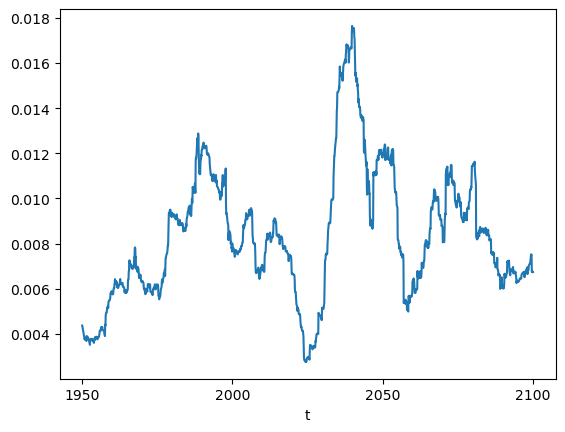

In [22]:
F_alpha.plot()

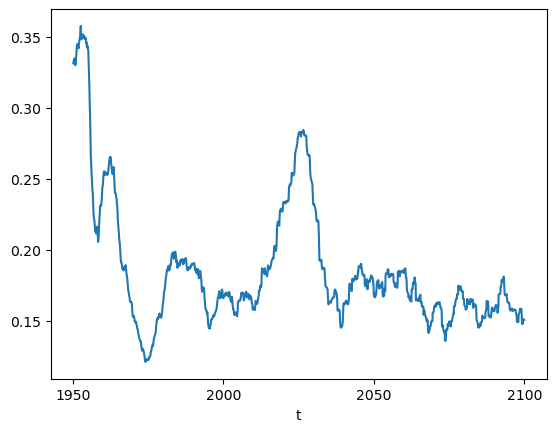

In [26]:
F_gamma.plot()

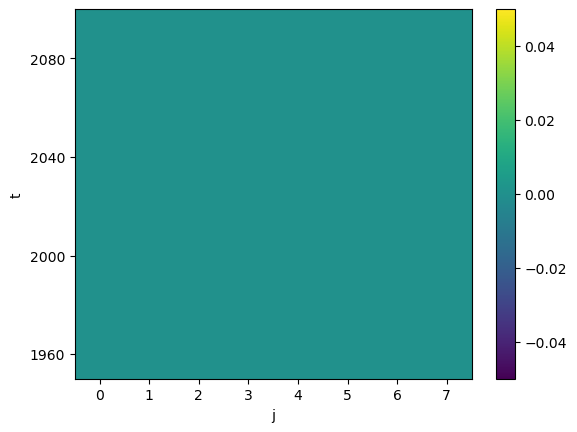

In [30]:
gamma_detectable = (
    (results["gamma_mean_ci_lower"] > 0)
    | (results["gamma_mean_ci_upper"] < 0)
)
gamma_detectable.plot()

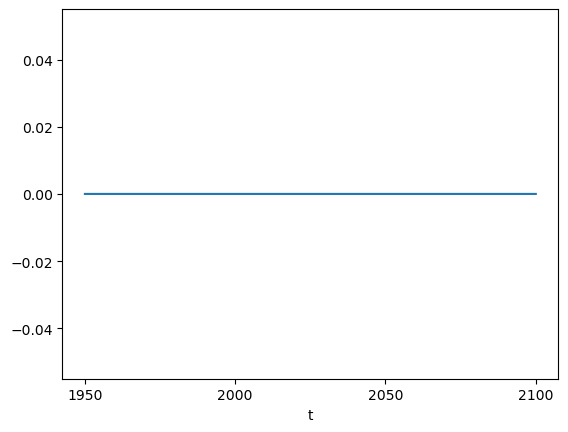

In [32]:
alpha_detectable = (
    (results["alpha_mean_ci_lower"] > 0)
    | (results["alpha_mean_ci_upper"] < 0)
)
alpha_detectable.plot()

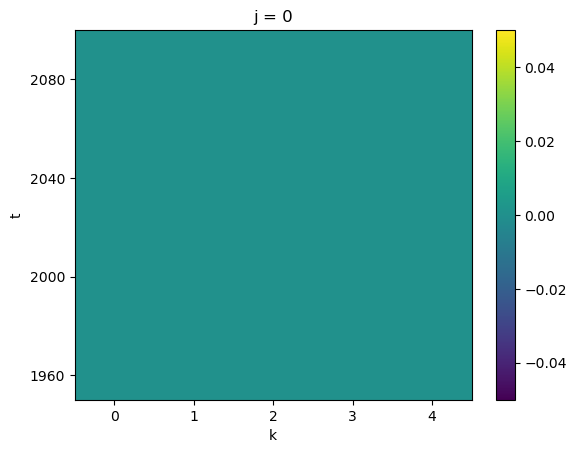

In [50]:
epsilon_detectable = (
    (results["epsilon_mean_ci_lower"] > 0)
    | (results["epsilon_mean_ci_upper"] < 0)
)
epsilon_detectable[:,0,:].plot()

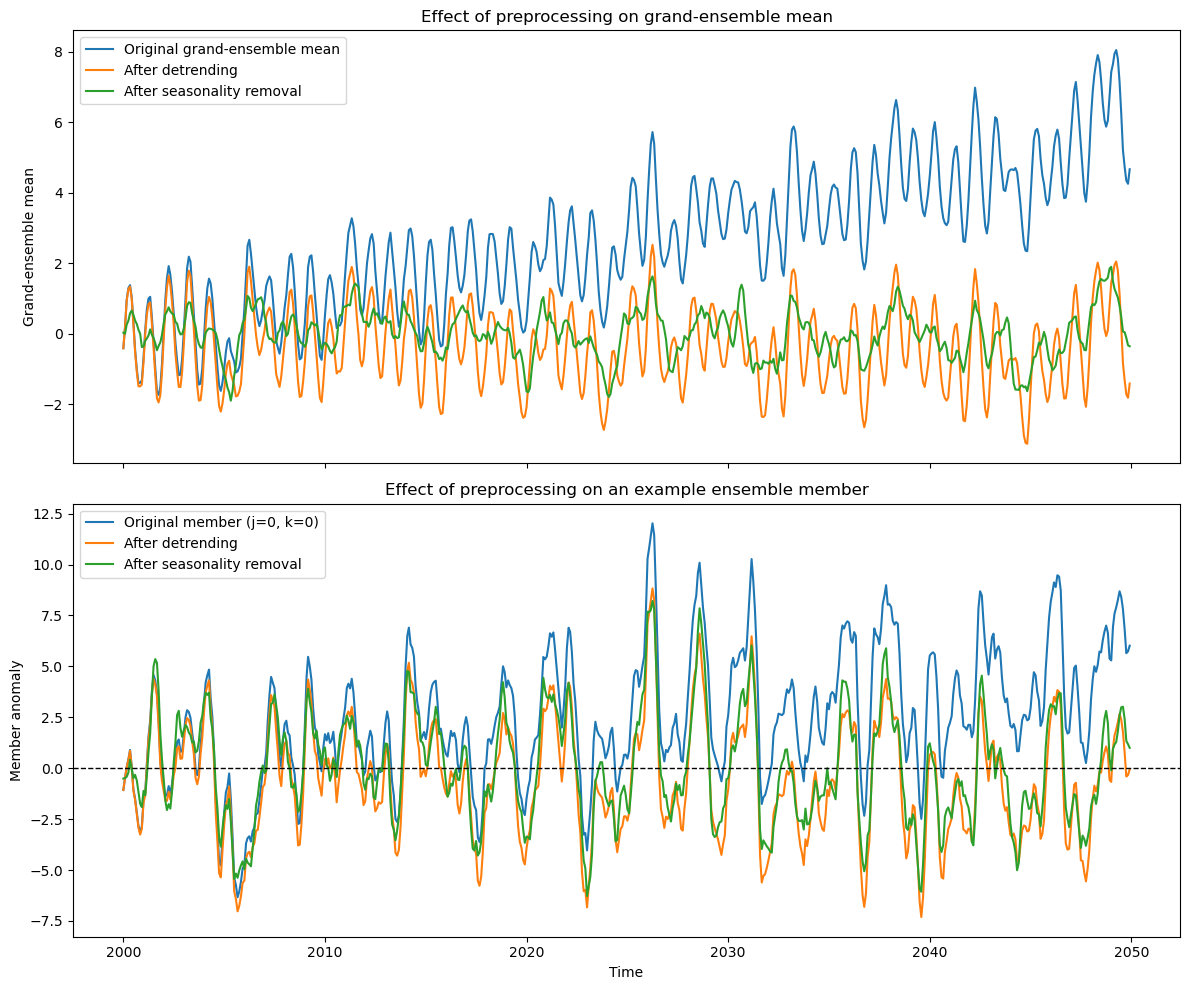

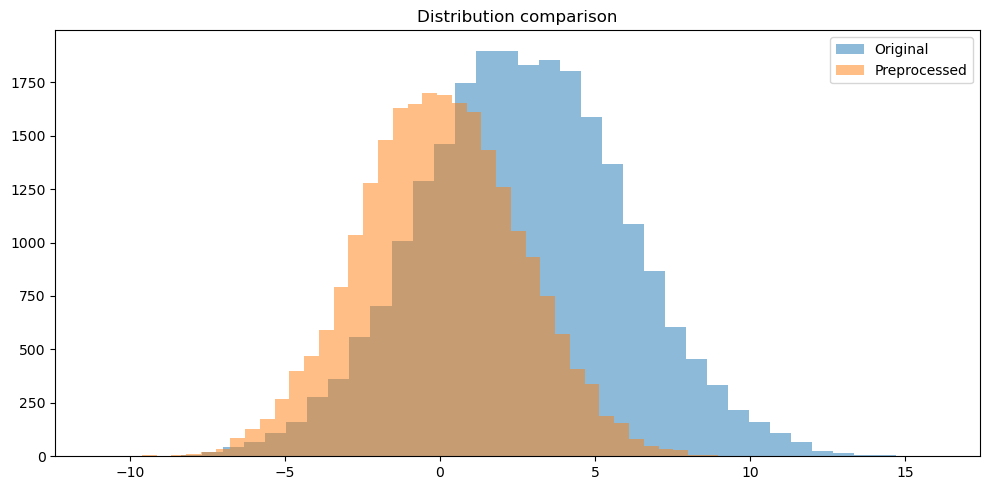

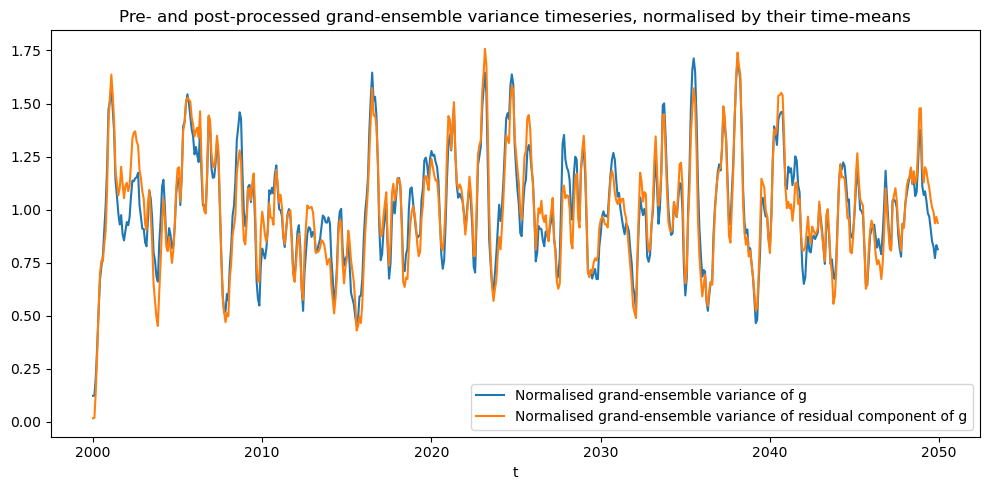

In [9]:
# ------------------------------------------------------------------
# 6. Produce all plots
# ------------------------------------------------------------------



plot_preprocessing_components(
    g,
    g_detrended,
    g_preprocessed,
    j_example=0,
    k_example=0,
    j_dim="j",
    k_dim="k",
    t_dim="t",
)


plot_distribution_comparison(
    g,
    g_preprocessed,
)

plot_normalized_variance(
    preprocessing_stats["ensemble_variance_original_norm"],
    preprocessing_stats["ensemble_variance_residual_norm"],
)


plt.show()

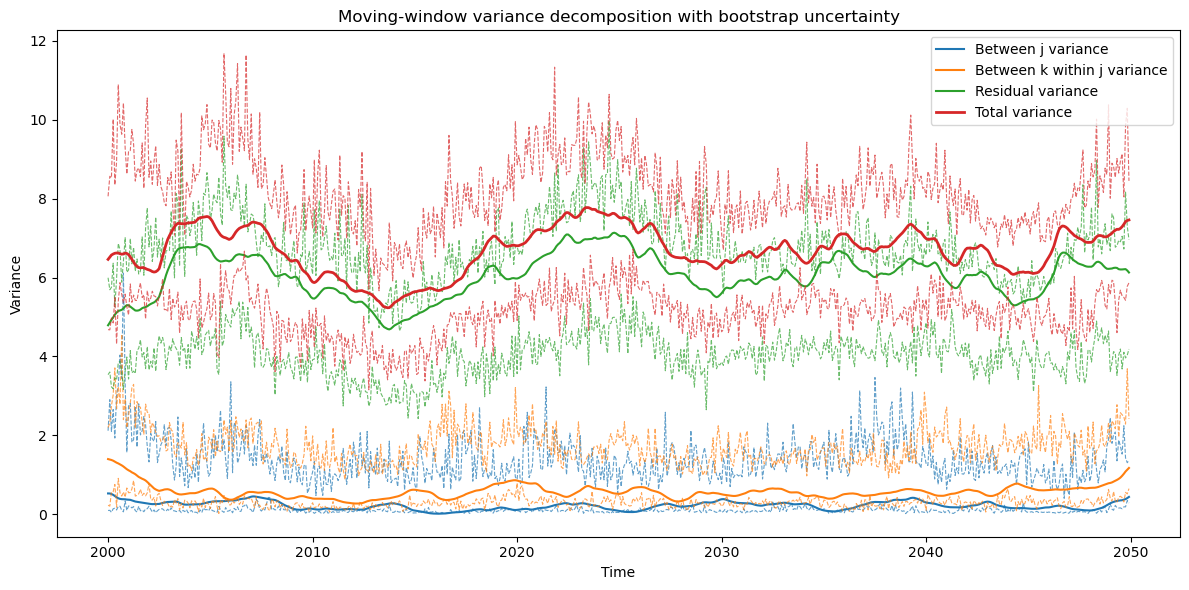

In [10]:
# ------------------------------------------------------------
# Plot variance components with bootstrap confidence intervals
# ------------------------------------------------------------


def plot_variance_decomposition_timeseries(
    result,
    t_dim="t",
):
    """
    Plot moving-window variance decomposition together with optional
    bootstrap confidence intervals.
    """

    fig, ax = plt.subplots(figsize=(12, 6))

    t = result[t_dim] if t_dim in result else np.arange(len(result))

    # ----------------------------------------------------------
    # Between-j variance
    # ----------------------------------------------------------
    line_j, = ax.plot(
        t,
        result["variance_between_j"],
        label="Between j variance",
    )

    if "variance_between_j_ci_lower" in result:
        ax.plot(
            t,
            result["variance_between_j_ci_lower"],
            color=line_j.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

        ax.plot(
            t,
            result["variance_between_j_ci_upper"],
            color=line_j.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

    # ----------------------------------------------------------
    # Between-k-within-j variance
    # ----------------------------------------------------------
    line_k, = ax.plot(
        t,
        result["variance_between_k_within_j"],
        label="Between k within j variance",
    )

    if "variance_between_k_within_j_ci_lower" in result:
        ax.plot(
            t,
            result["variance_between_k_within_j_ci_lower"],
            color=line_k.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

        ax.plot(
            t,
            result["variance_between_k_within_j_ci_upper"],
            color=line_k.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

    # ----------------------------------------------------------
    # Residual variance
    # ----------------------------------------------------------
    line_res, = ax.plot(
        t,
        result["residual_variance"],
        label="Residual variance",
    )

    if "residual_variance_ci_lower" in result:
        ax.plot(
            t,
            result["residual_variance_ci_lower"],
            color=line_res.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

        ax.plot(
            t,
            result["residual_variance_ci_upper"],
            color=line_res.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

    # ----------------------------------------------------------
    # Total variance
    # ----------------------------------------------------------
    line_tot, = ax.plot(
        t,
        result["total_variance"],
        label="Total variance",
        linewidth=2,
    )

    if "total_variance_ci_lower" in result:
        ax.plot(
            t,
            result["total_variance_ci_lower"],
            color=line_tot.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

        ax.plot(
            t,
            result["total_variance_ci_upper"],
            color=line_tot.get_color(),
            linewidth=0.8,
            alpha=0.7,
            linestyle="--",
        )

    ax.set_title(
        "Moving-window variance decomposition with bootstrap uncertainty"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Variance")
    ax.legend()

    plt.tight_layout()

    return fig, ax


plot_variance_decomposition_timeseries(results)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

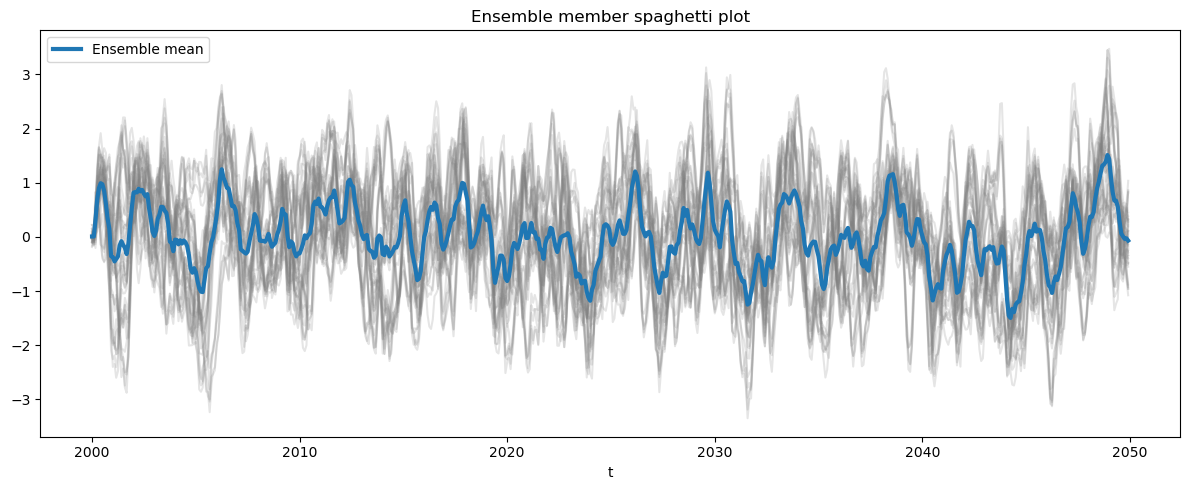

In [11]:
plot_member_spaghetti(g_preprocessed)
plt.show